# A Media Mix Model That Changes with Assumptions — A Practical Walkthrough

## A hands-on analysis using public data showing how adstock and saturation affect channel decisions.

---

## Business Question

> If I had to allocate marketing budget, which channels should I trust more?

## Core Insight

> The model is answering the question I asked — not necessarily the question I should have asked.

## Dataset

This notebook uses the Kaggle **Sample Media Spend Data** dataset.
>https://www.kaggle.com/datasets/yugagrawal95/sample-media-spends-data

The dataset has weekly observations by business division, sales, and marketing activity variables such as paid views, organic views, Google impressions, email impressions, Facebook impressions, affiliate impressions, and overall views.

## What this work demonstrates

Media Mix Modeling is not just regression. The business story can change when we add realistic marketing assumptions like:

- carryover / adstock,
- diminishing returns / saturation,
- trend and seasonality controls,
- division-level controls.

The goal is to show how MMM works and how to interpret it responsibly.

## 1. Setup and Data Loading

The first step is to load the dataset and inspect its structure.

Some columns are impressions or views rather than literal media spend. For this notebook, I interpret them as **marketing pressure variables**.

That distinction matters. If the inputs are impressions or views, I should avoid claiming strict ROI. A safer interpretation is:

> These variables show channel activity associated with sales, not direct dollar return.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH = "data/Sample Media Spend Data.csv"


df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Shape: (3051, 10)


,Division,Calendar_Week,Paid_Views,Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales
0,A,1/6/2018,392,422,408,"349,895.0107",73580,12072,682,59417
1,A,1/13/2018,787,904,110,"506,270.2176",11804,9499,853,56806
2,A,1/20/2018,81,970,742,"430,042.1538",52232,17048,759,48715
3,A,1/27/2018,25,575,65,"417,745.6658",78640,10207,942,72047
4,A,2/3/2018,565,284,295,"408,505.8012",40561,5834,658,56235


## 2. Column Setup and Basic Checks

For the MMM analysis:

- **Sales** is the target.
- **Calendar_Week** is the time variable.
- **Division** is a business-unit control.
- Media activity columns are the channel inputs.

Sorting by division and week is important because adstock depends on prior weeks.

In [2]:
date_col = "Calendar_Week"
division_col = "Division"
target_col = "Sales"

channel_cols = [
    "Paid_Views",
    "Organic_Views",
    "Google_Impressions",
    "Email_Impressions",
    "Facebook_Impressions",
    "Affiliate_Impressions",
    "Overall_Views",
]

required_cols = [date_col, division_col, target_col] + channel_cols
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values([division_col, date_col]).reset_index(drop=True)

print("Date range:", df[date_col].min(), "to", df[date_col].max())
print("Number of divisions:", df[division_col].nunique())

print("\nMissing values:")
display(df[required_cols].isna().sum().to_frame("missing_values"))

print("\nRows per division:")
display(df.groupby(division_col).size().describe().to_frame("rows_per_division"))

Date range: 2018-01-06 00:00:00 to 2020-02-29 00:00:00
Number of divisions: 26

Missing values:


,missing_values
Calendar_Week,0
Division,0
Sales,0
Paid_Views,0
Organic_Views,0
Google_Impressions,0
Email_Impressions,0
Facebook_Impressions,0
Affiliate_Impressions,0
Overall_Views,0



Rows per division:


,rows_per_division
count,26.0000
mean,117.3462
std,22.1611
min,113.0000
25%,113.0000
50%,113.0000
75%,113.0000
max,226.0000


## 3. First Look: Sales and Marketing Activity Over Time

Before modeling, I want to see whether sales and channel activity move together.

This is useful, but it is also where interpretation can go wrong.

If marketing activity rises when sales rise, that may mean marketing is working. But it could also mean the business increases activity when demand is already strong.

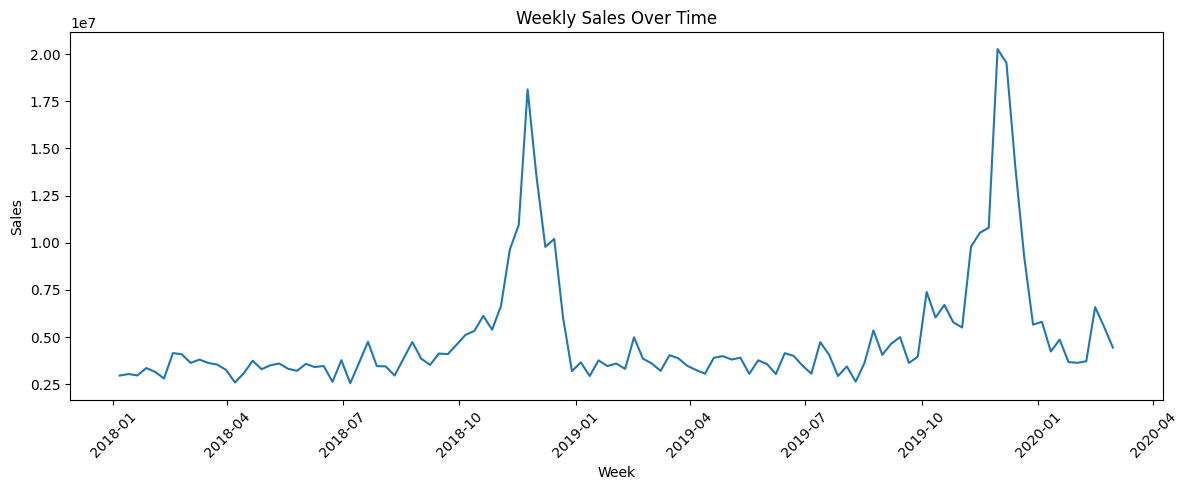

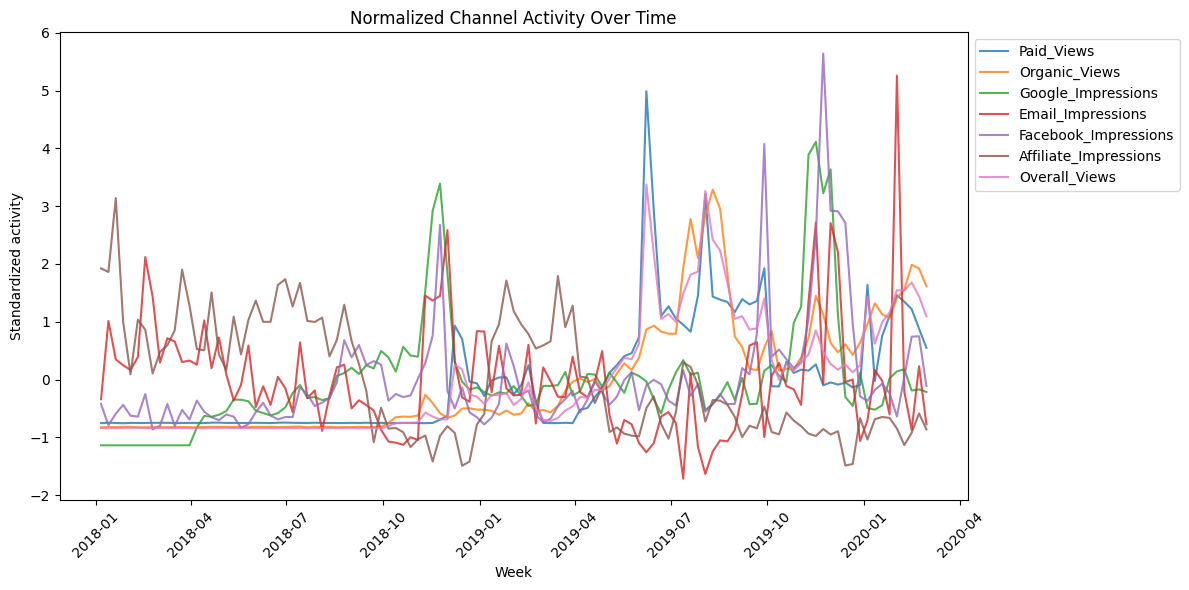

In [3]:
weekly = (
    df.groupby(date_col, as_index=False)
      .agg({target_col: "sum", **{c: "sum" for c in channel_cols}})
      .sort_values(date_col)
)

plt.figure(figsize=(12, 5))
plt.plot(weekly[date_col], weekly[target_col])
plt.title("Weekly Sales Over Time")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

normalized = weekly[[date_col] + channel_cols].copy()
for c in channel_cols:
    std = normalized[c].std()
    normalized[c] = 0 if std == 0 else (normalized[c] - normalized[c].mean()) / std

plt.figure(figsize=(12, 6))
for c in channel_cols:
    plt.plot(normalized[date_col], normalized[c], label=c, alpha=0.8)

plt.title("Normalized Channel Activity Over Time")
plt.xlabel("Week")
plt.ylabel("Standardized activity")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

This first look is descriptive, not causal.

A strong visual relationship between channel activity and sales can reflect true marketing impact, but it can also reflect seasonality, promotions, business cycles, or budget timing.

This is why I do not stop at one model. I compare multiple reasonable MMM specifications.

## 4. Time-Based Train/Test Split

For marketing time-series data, a random split can leak future patterns into training.

Instead, I use earlier weeks within each division for training and later weeks for testing.

This matches the practical use case:

> Train on historical data and evaluate on later periods.

In [4]:
df["week_index"] = df.groupby(division_col).cumcount()
df["month"] = df[date_col].dt.month.astype(str)
df["rank_pct"] = df.groupby(division_col)[date_col].rank(pct=True)

train_df = df[df["rank_pct"] <= 0.80].copy()
test_df = df[df["rank_pct"] > 0.80].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train date range:", train_df[date_col].min(), "to", train_df[date_col].max())
print("Test date range:", test_df[date_col].min(), "to", test_df[date_col].max())

Train shape: (2430, 13)
Test shape: (621, 13)
Train date range: 2018-01-06 00:00:00 to 2019-09-21 00:00:00
Test date range: 2019-09-28 00:00:00 to 2020-02-29 00:00:00


## 5. Baseline MMM: Raw Channel Variables

The baseline model is:

> Sales ~ raw channel activity + trend + month + division

I use Ridge regression because media variables often move together. Ridge helps stabilize coefficients when predictors are correlated.

This baseline does **not** yet account for:

- carryover effects,
- diminishing returns.

In [5]:
def fit_ridge_model(train, test, numeric_features, categorical_features, target=target_col):
    """
    Fit a Ridge regression model.

    Numeric features are standardized so channel coefficients are more comparable.
    Categorical features control for division and month.
    """
    all_features = numeric_features + categorical_features

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 25))),
        ]
    )

    model.fit(train[all_features], train[target])
    pred = model.predict(test[all_features])

    rmse = mean_squared_error(test[target], pred) ** 0.5
    r2 = r2_score(test[target], pred)

    feature_names = model.named_steps["preprocessor"].get_feature_names_out()
    coefs = pd.Series(model.named_steps["ridge"].coef_, index=feature_names)

    return model, pred, rmse, r2, coefs

categorical_features = [division_col, "month"]
baseline_numeric = channel_cols + ["week_index"]

baseline_model, baseline_pred, baseline_rmse, baseline_r2, baseline_coefs = fit_ridge_model(
    train_df, test_df, baseline_numeric, categorical_features
)

baseline_importance = (
    pd.DataFrame({
        "channel": channel_cols,
        "standardized_coefficient": [
            baseline_coefs.get(f"num__{c}", np.nan) for c in channel_cols
        ],
    })
    .assign(abs_coefficient=lambda x: x["standardized_coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)

print(f"Baseline RMSE: {baseline_rmse:,.0f}")
print(f"Baseline R²: {baseline_r2:,.3f}")
display(baseline_importance)

Baseline RMSE: 179,468
Baseline R²: 0.725


,channel,standardized_coefficient,abs_coefficient
3,Email_Impressions,"78,017.2968","78,017.2968"
2,Google_Impressions,"71,915.0801","71,915.0801"
4,Facebook_Impressions,"45,174.4073","45,174.4073"
5,Affiliate_Impressions,"-25,109.5039","25,109.5039"
6,Overall_Views,"4,661.7123","4,661.7123"
1,Organic_Views,"-2,993.8821","2,993.8821"
0,Paid_Views,"2,283.0991","2,283.0991"


### Baseline Interpretation

The baseline model tells us which channel variables are most strongly associated with sales after controlling for division, month, and trend.

This is useful, but incomplete. It assumes marketing activity affects sales only in the same week.

In real marketing, that is often too simplistic.

## 6. Adding Adstock: Carryover Effects

Adstock captures the idea that marketing can keep influencing customers after the initial exposure.

A simple geometric adstock formula is:

$$
Adstock_t = X_t + \lambda \cdot Adstock_{t-1}
$$

where $\lambda$ is the decay rate.

A higher decay rate assumes that marketing effects last longer, while a lower decay rate assumes they fade quickly.

In [6]:
def add_geometric_adstock(data, cols, group_col, decay):
    """
    Create geometric adstock features within each division.

    This must be computed separately by division.
    Otherwise, activity from one division would incorrectly carry into another.
    """
    out = data.copy()

    for c in cols:
        new_col = f"{c}_adstock"
        out[new_col] = np.nan

        for _, idx in out.groupby(group_col).groups.items():
            carry = 0.0
            values = out.loc[idx, c].fillna(0).values
            transformed = []

            for x in values:
                carry = x + decay * carry
                transformed.append(carry)

            out.loc[idx, new_col] = transformed

    return out

decay = 0.50
df_adstock = add_geometric_adstock(df, channel_cols, division_col, decay=decay)
adstock_cols = [f"{c}_adstock" for c in channel_cols]

train_adstock = df_adstock[df_adstock["rank_pct"] <= 0.80].copy()
test_adstock = df_adstock[df_adstock["rank_pct"] > 0.80].copy()

adstock_model, adstock_pred, adstock_rmse, adstock_r2, adstock_coefs = fit_ridge_model(
    train_adstock, test_adstock, adstock_cols + ["week_index"], categorical_features
)

adstock_importance = (
    pd.DataFrame({
        "channel": channel_cols,
        "standardized_coefficient": [
            adstock_coefs.get(f"num__{c}_adstock", np.nan) for c in channel_cols
        ],
    })
    .assign(abs_coefficient=lambda x: x["standardized_coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)

print(f"Adstock RMSE: {adstock_rmse:,.0f}")
print(f"Adstock R²: {adstock_r2:,.3f}")
display(adstock_importance)

Adstock RMSE: 158,069
Adstock R²: 0.787


,channel,standardized_coefficient,abs_coefficient
3,Email_Impressions,"95,954.1740","95,954.1740"
4,Facebook_Impressions,"67,117.3569","67,117.3569"
2,Google_Impressions,"59,936.9599","59,936.9599"
5,Affiliate_Impressions,"-35,954.6034","35,954.6034"
0,Paid_Views,"-17,646.9903","17,646.9903"
1,Organic_Views,"14,164.0256","14,164.0256"
6,Overall_Views,"7,974.5337","7,974.5337"


### What Changed After Adstock?

This is the first important practitioner moment.

If performance improves after adstock, it suggests same-week activity alone is not enough. The model benefits from allowing marketing impact to persist.

If the channel ranking changes, the business story also changes.

> Adstock is not just a technical transformation. It is a business assumption about how long marketing effects last.

## 7. Adding Saturation: Diminishing Returns

Saturation captures the idea that more marketing activity does not always produce proportional sales impact.

Here I use:

$$
\log(1 + Adstock)
$$

This compresses very large values and reflects diminishing marginal response.

In [7]:
df_sat = df_adstock.copy()

for c in adstock_cols:
    df_sat[f"log_{c}"] = np.log1p(df_sat[c])

sat_cols = [f"log_{c}" for c in adstock_cols]

train_sat = df_sat[df_sat["rank_pct"] <= 0.80].copy()
test_sat = df_sat[df_sat["rank_pct"] > 0.80].copy()

sat_model, sat_pred, sat_rmse, sat_r2, sat_coefs = fit_ridge_model(
    train_sat, test_sat, sat_cols + ["week_index"], categorical_features
)

sat_importance = (
    pd.DataFrame({
        "channel": channel_cols,
        "standardized_coefficient": [
            sat_coefs.get(f"num__log_{c}_adstock", np.nan) for c in channel_cols
        ],
    })
    .assign(abs_coefficient=lambda x: x["standardized_coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)

print(f"Adstock + Saturation RMSE: {sat_rmse:,.0f}")
print(f"Adstock + Saturation R²: {sat_r2:,.3f}")
display(sat_importance)

Adstock + Saturation RMSE: 217,167
Adstock + Saturation R²: 0.597


,channel,standardized_coefficient,abs_coefficient
3,Email_Impressions,"97,043.5603","97,043.5603"
4,Facebook_Impressions,"53,021.8812","53,021.8812"
0,Paid_Views,"-37,644.8650","37,644.8650"
6,Overall_Views,"35,467.2920","35,467.2920"
1,Organic_Views,"34,214.8591","34,214.8591"
5,Affiliate_Impressions,"3,946.2263","3,946.2263"
2,Google_Impressions,"1,958.9338","1,958.9338"


### Saturation Interpretation

Saturation is conceptually realistic, but it does not automatically improve a model.

If saturation improves performance, the data supports diminishing returns. If it does not, the lesson is still useful:

> A reasonable marketing assumption still needs empirical validation.

This is why MMM is a sequence of decisions, not a single mechanical recipe.

## 8. Model Comparison: Does the Story Change?

Now I compare:

1. Baseline raw-channel model
2. Adstock model
3. Adstock + saturation model

The key question is not only which model has the highest R². The bigger question is:

> Does the implied channel recommendation change?

,model,rmse,r2
0,Baseline,"179,468.4869",0.7249
1,Adstock,"158,069.1247",0.7866
2,Adstock + Saturation,"217,166.6132",0.5972


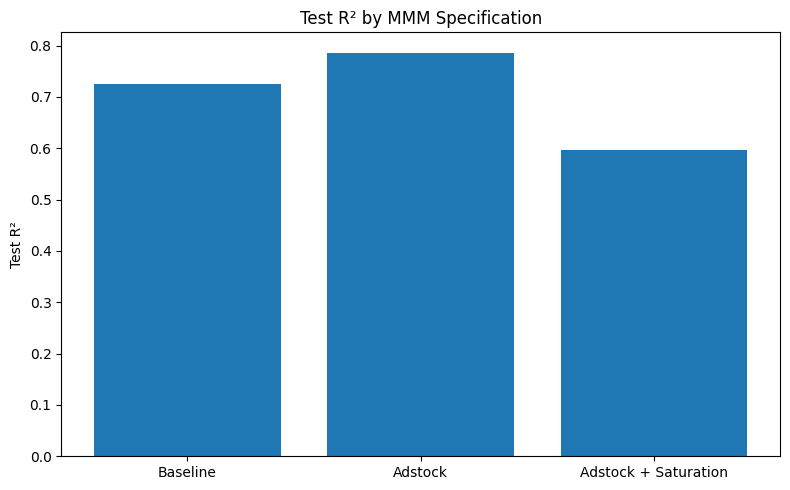

,model,rank,channel,standardized_coefficient,abs_coefficient
7,Adstock,1,Email_Impressions,"95,954.1740","95,954.1740"
8,Adstock,2,Facebook_Impressions,"67,117.3569","67,117.3569"
9,Adstock,3,Google_Impressions,"59,936.9599","59,936.9599"
10,Adstock,4,Affiliate_Impressions,"-35,954.6034","35,954.6034"
11,Adstock,5,Paid_Views,"-17,646.9903","17,646.9903"
12,Adstock,6,Organic_Views,"14,164.0256","14,164.0256"
13,Adstock,7,Overall_Views,"7,974.5337","7,974.5337"
14,Adstock + Saturation,1,Email_Impressions,"97,043.5603","97,043.5603"
15,Adstock + Saturation,2,Facebook_Impressions,"53,021.8812","53,021.8812"
16,Adstock + Saturation,3,Paid_Views,"-37,644.8650","37,644.8650"


In [8]:
comparison = pd.DataFrame({
    "model": ["Baseline", "Adstock", "Adstock + Saturation"],
    "rmse": [baseline_rmse, adstock_rmse, sat_rmse],
    "r2": [baseline_r2, adstock_r2, sat_r2],
})

display(comparison)

plt.figure(figsize=(8, 5))
plt.bar(comparison["model"], comparison["r2"])
plt.title("Test R² by MMM Specification")
plt.ylabel("Test R²")
plt.tight_layout()
plt.show()

def rank_table(imp, name):
    out = imp.copy()
    out["rank"] = out["abs_coefficient"].rank(method="first", ascending=False).astype(int)
    out["model"] = name
    return out[["model", "rank", "channel", "standardized_coefficient", "abs_coefficient"]]

ranks = pd.concat([
    rank_table(baseline_importance, "Baseline"),
    rank_table(adstock_importance, "Adstock"),
    rank_table(sat_importance, "Adstock + Saturation"),
], ignore_index=True)

display(ranks.sort_values(["model", "rank"]))

## Key Insight: The Model Didn’t Change — My Assumptions Did

The most important realization from this exercise is:

> The data stayed the same, but my conclusions changed.

Changing adstock decay or adding saturation can change channel rankings.

This means:

> MMM does not give a single truth — it gives answers conditional on assumptions.

That does not make MMM useless. It makes sensitivity testing essential.

## 9. Sensitivity Check: Changing Adstock Decay

Adstock decay is one of the most important assumptions. It answers:

> How long do we believe marketing impact lasts?

Here I test multiple decay values and compare model performance and top-ranked channels.

,decay,rmse,r2,top_channel
0,0.1000,"174,412.2726",0.7402,Email_Impressions
1,0.3000,"163,571.2197",0.7715,Email_Impressions
2,0.5000,"158,069.1247",0.7866,Email_Impressions
3,0.7000,"178,824.4316",0.7268,Facebook_Impressions
4,0.9000,"239,783.9952",0.5089,Facebook_Impressions


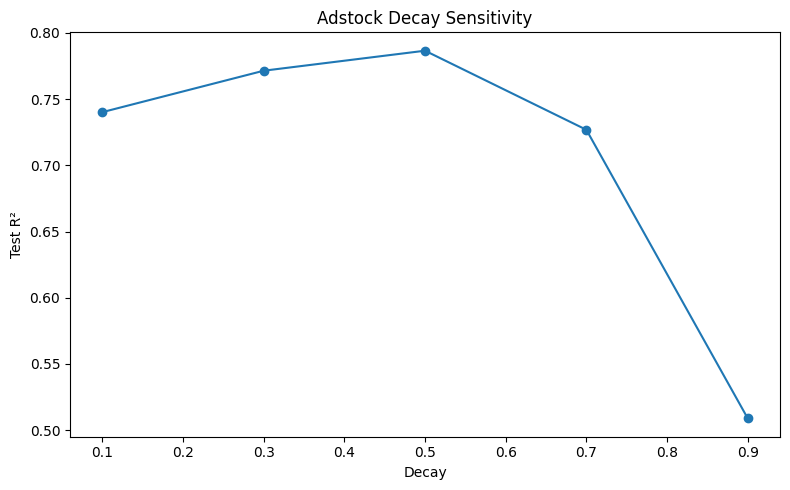

In [9]:
sensitivity_rows = []

for decay_value in [0.10, 0.30, 0.50, 0.70, 0.90]:
    temp = add_geometric_adstock(df, channel_cols, division_col, decay=decay_value)
    temp_cols = [f"{c}_adstock" for c in channel_cols]

    temp_train = temp[temp["rank_pct"] <= 0.80].copy()
    temp_test = temp[temp["rank_pct"] > 0.80].copy()

    _, _, rmse, r2, coefs = fit_ridge_model(
        temp_train, temp_test, temp_cols + ["week_index"], categorical_features
    )

    scores = [(c, abs(coefs.get(f"num__{c}_adstock", 0))) for c in channel_cols]
    top_channel = sorted(scores, key=lambda x: x[1], reverse=True)[0][0]

    sensitivity_rows.append({
        "decay": decay_value,
        "rmse": rmse,
        "r2": r2,
        "top_channel": top_channel,
    })

sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity)

plt.figure(figsize=(8, 5))
plt.plot(sensitivity["decay"], sensitivity["r2"], marker="o")
plt.title("Adstock Decay Sensitivity")
plt.xlabel("Decay")
plt.ylabel("Test R²")
plt.tight_layout()
plt.show()

## A Small Change That Flipped the Story

Changing adstock decay is not a small technical detail. It changes the assumed memory of the channel.

- Low decay means the model favors short-term response.
- High decay means the model allows longer-lasting exposure effects.

Nothing in the data changed — only the assumption changed.

> Channel importance depends partly on assumed memory.

If the top channel changes across decay assumptions, I would not make a large budget recommendation from a single MMM run.

## If Only One Model Was Presented

If I presented only one model, I might confidently recommend increasing activity in one channel.

But after testing variations, that recommendation may no longer be stable.

This shows a real risk:

> MMM can create false confidence if sensitivity is not tested.

A stronger recommendation is not “Channel X is best.” A stronger recommendation is:

> “Channel X is consistently strong across these assumptions, while Channel Y is sensitive to the model specification.”

## 10. If I Used This for Budget Decisions

A weak interpretation would be:

> “The model says this channel caused the most sales.”

A stronger interpretation is:

> “This channel is consistently associated with sales across several MMM specifications. However, the recommendation should be stress-tested with alternative adstock values, saturation curves, and ideally experimental validation.”

That is the level of caution I would use in a real marketing analytics discussion.

## Final Takeaway

> MMM does not give a single answer — it gives a range of answers depending on assumptions.

The real value is understanding:

- what is stable,
- what is assumption-driven,
- what should be tested further.

That distinction makes MMM useful for decision-making.

MMM is most valuable when it is used to structure decision-making, not when it is treated as a black-box budget allocator.